In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import os

base_path = "EDA_Daten"

all_measurements = []  
measurement_id = 0      

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    
    # Nur Unterordner nehmen
    if os.path.isdir(folder_path):
        
        try:
            # CSVs laden
            acceleration = pd.read_csv(os.path.join(folder_path, "Accelerometer.csv"))
            gravity = pd.read_csv(os.path.join(folder_path, "Gravity.csv"))
            gyroscope = pd.read_csv(os.path.join(folder_path, "Gyroscope.csv"))
            tag = pd.read_csv(os.path.join(folder_path, "Tags.csv"))
            
            
            acceleration["Sensor"] = "Accelerometer"
            gravity["Sensor"] = "Gravity"
            gyroscope["Sensor"] = "Gyroscope"
            
            data = pd.concat([acceleration, gravity, gyroscope], ignore_index=True)
            
            # Zeit konvertieren 
            data["time"] = pd.to_datetime(data["time"])
            
            # Tag setzen
            data["Tag"] = tag["tag"].iloc[0]
            
            # Messungs-ID setzen
            data["ID"] = measurement_id
            
            measurement_id += 1
            
            # Speichern
            all_measurements.append(data)
        
        except Exception as e:
            print(f"Fehler in Ordner {folder}: {e}")

# Alle Messungen zusammenführen
final_df = pd.concat(all_measurements, ignore_index=True)



In [11]:
def trim_measurement(group, trim_seconds=3):
    min_time = group["seconds_elapsed"].min()
    max_time = group["seconds_elapsed"].max()
    return group.loc[
        (group["seconds_elapsed"] >= min_time + trim_seconds) &
        (group["seconds_elapsed"] <= max_time - trim_seconds)
    ]

# ID als separate Spalte sichern bevor groupby sie verschluckt
final_df["ID_backup"] = final_df["ID"]

final_df_trimmed = (
    final_df
    .groupby("ID_backup", group_keys=False)
    .apply(trim_measurement)
    .reset_index(drop=True)
)


In [12]:
final_df_trimmed

,time,seconds_elapsed,z,y,x,Sensor,Tag,ID
0,2026-03-03 10:42:50.960621300,3.259621,0.650506,2.949518,1.446072,Accelerometer,Treppe runter,0
1,2026-03-03 10:42:50.970531000,3.269531,0.272985,2.613810,0.252541,Accelerometer,Treppe runter,0
2,2026-03-03 10:42:50.980440800,3.279441,0.918067,0.648394,-1.411997,Accelerometer,Treppe runter,0
3,2026-03-03 10:42:50.990350600,3.289351,1.931937,-3.180973,-4.285746,Accelerometer,Treppe runter,0
4,2026-03-03 10:42:51.000260600,3.299260,1.467552,-2.795876,-4.884227,Accelerometer,Treppe runter,0
...,...,...,...,...,...,...,...,...
249170,2026-03-11 12:41:12.405726500,10.059727,2.076525,-0.963600,1.060262,Gyroscope,Treppe hoch,30
249171,2026-03-11 12:41:12.425546200,10.079546,1.329350,-0.908188,0.382387,Gyroscope,Treppe hoch,30
249172,2026-03-11 12:41:12.445365500,10.099365,0.419513,-0.572963,0.298375,Gyroscope,Treppe hoch,30
249173,2026-03-11 12:41:12.465185000,10.119185,0.027912,-0.580525,0.224950,Gyroscope,Treppe hoch,30


In [13]:
final_df_trimmed[final_df_trimmed["ID"] == 27]

,time,seconds_elapsed,z,y,x,Sensor,Tag,ID
235629,2026-03-10 17:18:26.029225200,3.115225,-3.069695,-0.414022,0.280410,Accelerometer,120,27
235630,2026-03-10 17:18:26.037558300,3.123558,-3.448555,-0.138364,0.093686,Accelerometer,120,27
235631,2026-03-10 17:18:26.045891300,3.131891,-3.485038,0.268738,0.064014,Accelerometer,120,27
235632,2026-03-10 17:18:26.054224400,3.140224,-3.411349,0.622866,0.132524,Accelerometer,120,27
235633,2026-03-10 17:18:26.062557200,3.148557,-3.147469,0.925835,0.228922,Accelerometer,120,27
...,...,...,...,...,...,...,...,...
241279,2026-03-10 17:18:42.455306200,19.541306,-2.740340,-2.582584,-0.460134,Gyroscope,120,27
241280,2026-03-10 17:18:42.464688400,19.550688,-3.293783,-3.545306,-0.467464,Gyroscope,120,27
241281,2026-03-10 17:18:42.474070500,19.560071,-3.852113,-4.619207,-0.579863,Gyroscope,120,27
241282,2026-03-10 17:18:42.483452400,19.569452,-4.201528,-5.478083,-0.704480,Gyroscope,120,27


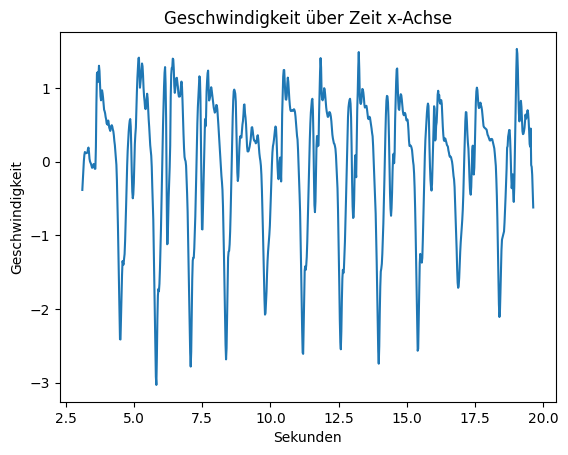

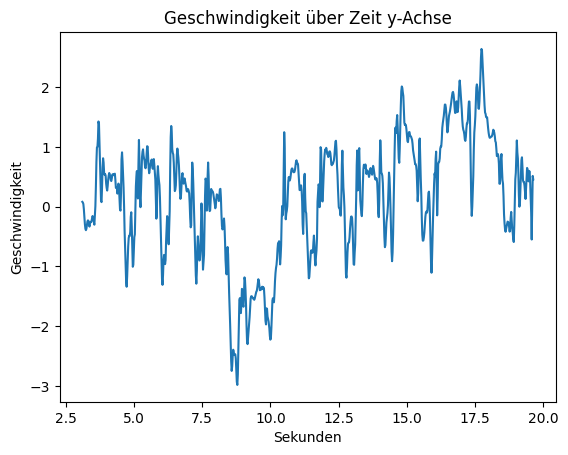

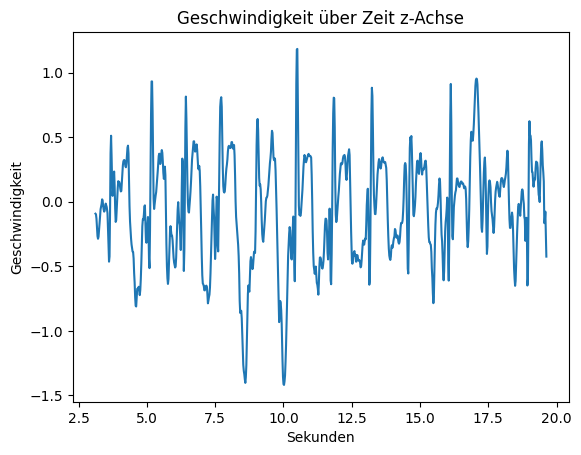

In [14]:
speed = final_df_trimmed[(final_df_trimmed["Sensor"] == "Gyroscope") & (final_df_trimmed['ID'] == 23)]

#Diagramm mit Sekunden auf der x-Achse und Geschwindigkeit auf der y-Achse.
plt.plot(speed['seconds_elapsed'], speed["x"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit x-Achse")
plt.show()

plt.plot(speed['seconds_elapsed'], speed["y"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit y-Achse")
plt.show()

plt.plot(speed['seconds_elapsed'], speed["z"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit z-Achse")
plt.show()